In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

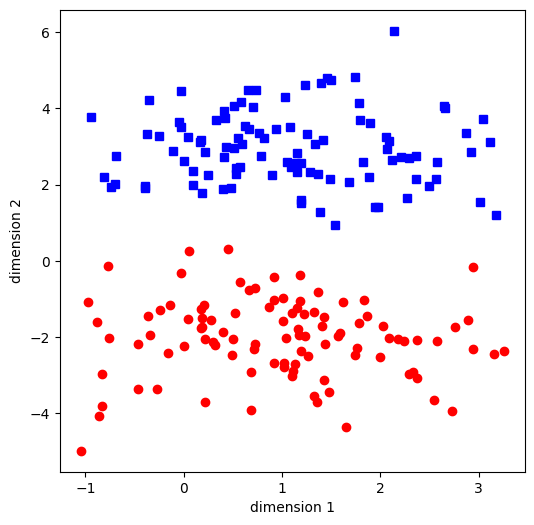

In [ ]:
#create data

nPerClust = 100
blur = 1 #std deviation multiplier for gaussian noise

A = [1,3]
B = [1,-2]

#Generate Data
a = [A[0]+np.random.randn(nPerClust)*blur,A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur,B[1]+np.random.randn(nPerClust)*blur]

#true labels
labels_np = np.vstack((np.zeros((nPerClust,1)), np.ones((nPerClust,1))))

#concatenate into a matrix
data_np = np.hstack((a,b)).T

#convert to pytorch
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

#plot the data
fig = plt.figure(figsize=(6,6))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ro')
plt.xlabel('dimension 1')
plt.ylabel('dimension 2')
plt.show()

# Build and train the Model

In [ ]:
data.shape

torch.Size([200, 2])

In [ ]:
def ANNModel(learningRate):
  #model architecture
  ANNclassify = nn.Sequential(
      nn.Linear(2,16), #input layer
      nn.ReLU(), #activation unit
      nn.Linear(16,1), #hidden layer
      nn.ReLU(),
      nn.Linear(1,1),
      nn.Sigmoid(), #final activation unit
  )

  #loss function
  lossfun = nn.BCELoss() #BCEWithLogitsLoss = Sigmoid + BCELoss combined in one numerically stable operation

  ##optimizer
  optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate)

  #model output
  return ANNclassify, lossfun, optimizer



In [ ]:
#Model training

numepochs = 1000

def trainTheModel(ANNModel):

  #initialize losses
  losses = torch.zeros(numepochs)

  #loop over epochs
  for ep in range(numepochs):

    #forward pass
    yHat = ANNModel(data)

    #compute loss
    loss = lossfun(yHat,labels)

    losses[ep] = loss

    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

#final forward pass
  predictions = ANNModel(data)

  #compute the predictions and reporting accuracy
  totalacc = 100*torch.mean(((predictions>0.5) == labels).float())

  return losses, predictions, totalacc

In [ ]:
float(False)

0.0

In [ ]:
#Testing the model

ANNclassify, lossfun, optimizer = ANNModel(learningRate=0.01)

losses, predictions, totalacc   = trainTheModel(ANNclassify)

In [ ]:
print(f"Final Accuracy : {np.round(totalacc,2)}")

Final Accuracy : 99.0


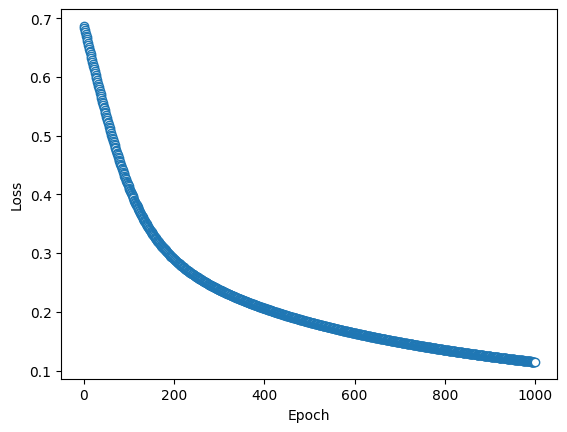

In [ ]:
plt.plot(losses.detach(),'o',mfc='white',lw=0.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()